In [51]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [52]:
MODEL_PATH = "../models/resnet50_adam_finetune.h5"
model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False)

print("Model loaded successfully")

Model loaded successfully


In [54]:
TEST_DIR = "../data/test"

test_images = os.listdir(TEST_DIR)

print(len(test_images))
print(test_images[:5])

175
['vid_5_25100.jpg', 'vid_5_25120.jpg', 'vid_5_25140.jpg', 'vid_5_25160.jpg', 'vid_5_25180.jpg']


In [55]:
def predict_image(image_path):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    img_resized = cv2.resize(img, (224, 224))
    
    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0]

    xmin = int(pred[0] * w)
    ymin = int(pred[1] * h)
    xmax = int(pred[2] * w)
    ymax = int(pred[3] * h)

    return img, (xmin, ymin, xmax, ymax), pred

In [56]:
def visualize_prediction(image_path):

    img, (xmin, ymin, xmax, ymax), pred = predict_image(image_path)

    print("Prediction:", pred)

    cv2.rectangle(
        img,
        (xmin, ymin),
        (xmax, ymax),
        (0,255,0),
        2
    )

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: [0.37441936 0.37561122 0.47889662 0.82343185]


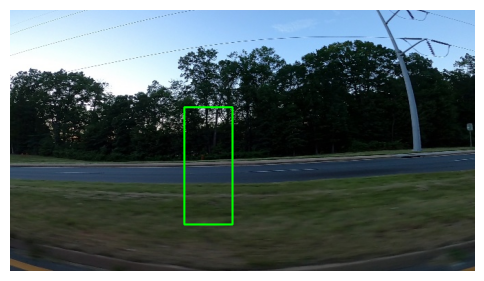

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Prediction: [0.3673159  0.39608493 0.5312978  0.8317802 ]


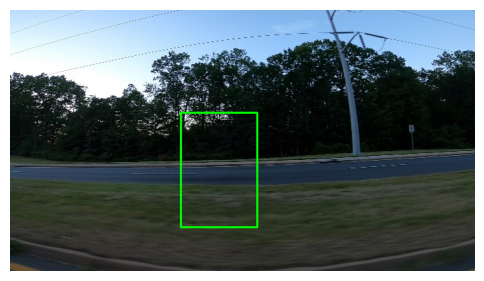

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Prediction: [0.3445652  0.39986202 0.52474713 0.8453854 ]


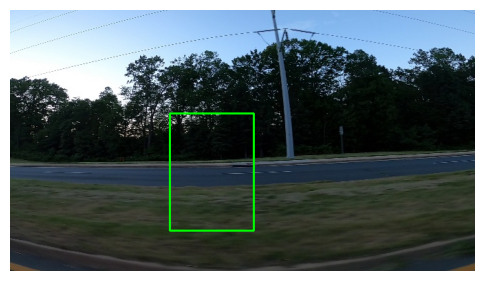

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Prediction: [0.4036934  0.40864816 0.5192536  0.8607326 ]


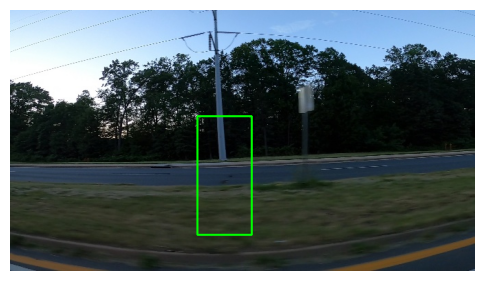

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Prediction: [0.37484843 0.40547568 0.5454227  0.8444897 ]


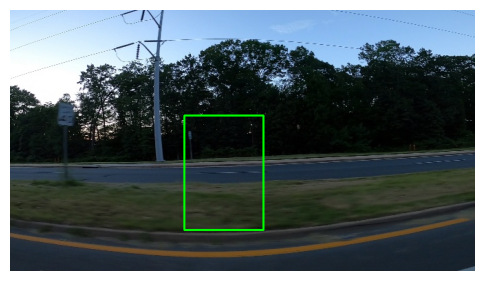

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Prediction: [0.36295488 0.40111148 0.52892435 0.80172503]


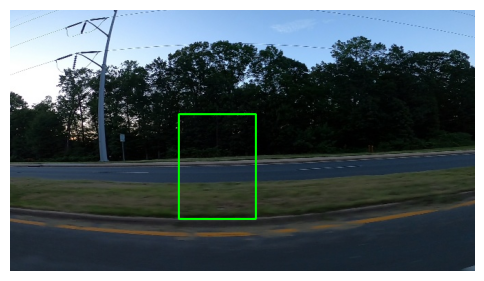

In [57]:
for i in range(6):

    sample = os.path.join(TEST_DIR, test_images[i])
    
    visualize_prediction(sample)

In [58]:
OUTPUT_DIR = "../evaluation/predictions"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [59]:
def save_prediction(image_path, save_path):
    
    img, (xmin, ymin, xmax, ymax) = predict_image(image_path)
    
    cv2.rectangle(
        img,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        2
    )
    
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    
    cv2.imwrite(save_path, img)

Image: vid_5_27580.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


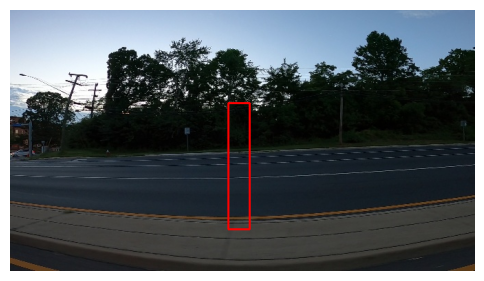

Image: vid_5_27600.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


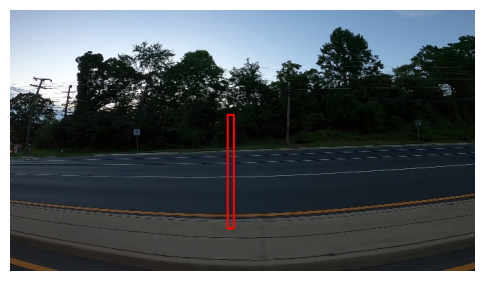

Image: vid_5_27620.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


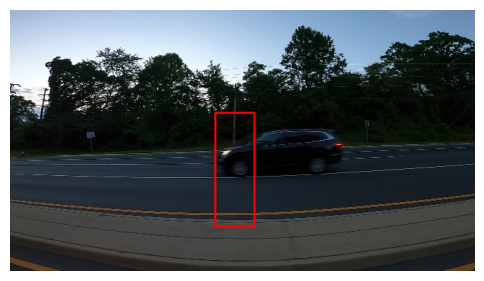

Image: vid_5_27640.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


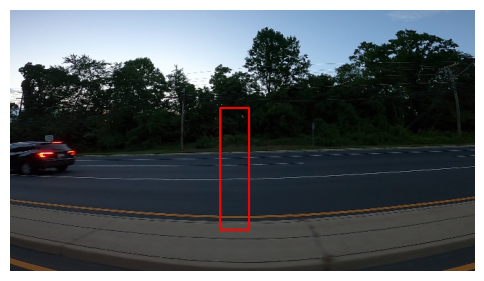

Image: vid_5_27660.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


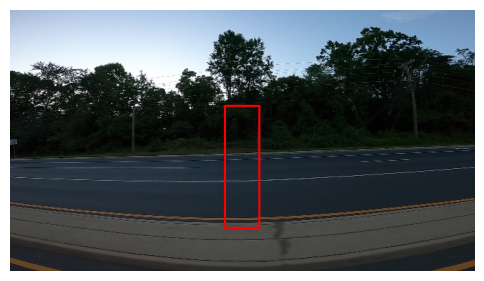

In [ ]:
for i in range(50, 55):
    
    sample = os.path.join(TEST_DIR, test_images[i])
    
    print("Image:", test_images[i])
    visualize_prediction(sample)